In [1]:
# Cell 1
import rasterio
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 10)

def load_reflectance(band_name):
    """Loads a band and converts it to physical reflectance (0.0 to 1.0)"""
    with rasterio.open(f"data/s2_{band_name}.tif") as src:
        pixels = src.read(1).astype(float)
        return np.clip(pixels / 10000.0, 0.0, 1.0)

# Load the bands we need for indices
green = load_reflectance("B03")
red = load_reflectance("B04")
nir = load_reflectance("B08")

# In math, dividing by zero causes computer crashes. 
# We tell numpy to ignore "Divide by Zero" warnings since some pixels might be 0.
np.seterr(divide='ignore', invalid='ignore')
print("Data loaded and ready for math!")


Data loaded and ready for math!


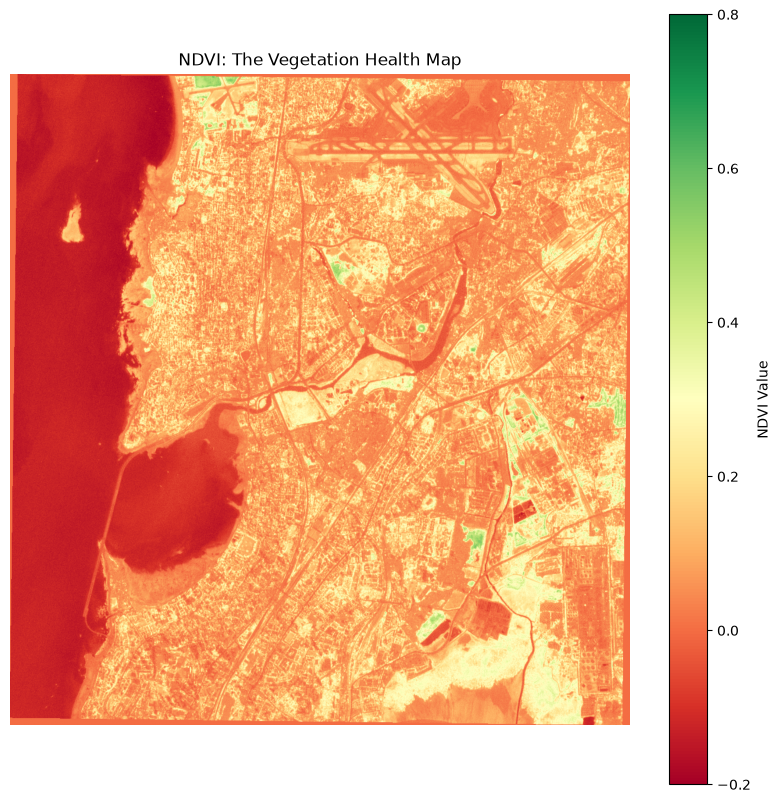

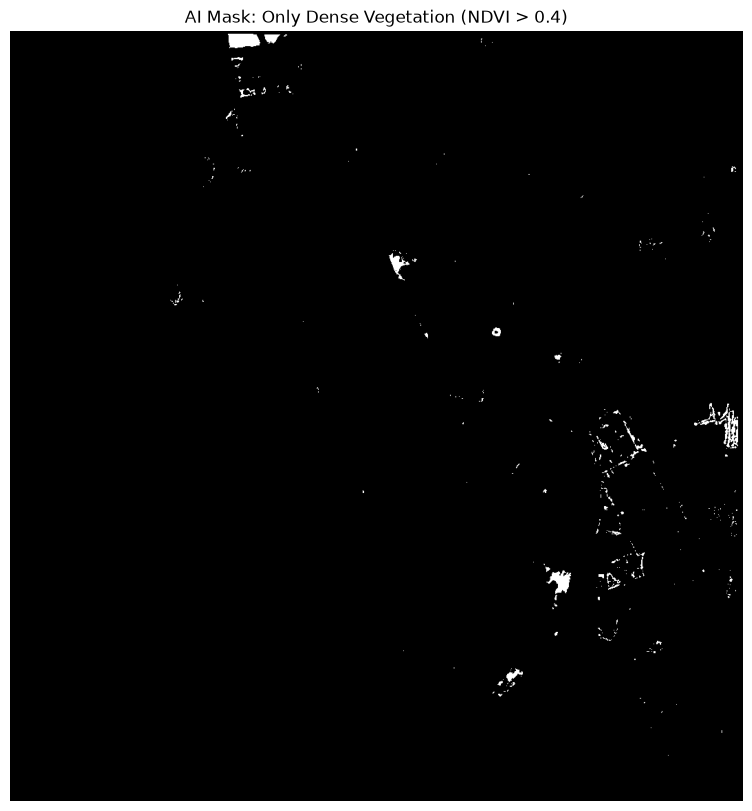

In [2]:
# Cell 2
# 1. Calculate NDVI using pure math
# We use np.where to say: "If the bottom of the fraction is 0, just make the answer 0"
ndvi_bottom = (nir + red)
ndvi = np.where(ndvi_bottom == 0, 0, (nir - red) / ndvi_bottom)

# 2. Plot the raw NDVI scale
plt.figure()
# We use a 'RdYlGn' (Red-Yellow-Green) colormap. 
# Low values (soil/water) are red/yellow, high values (trees) are deep green.
plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.colorbar(label='NDVI Value')
plt.title("NDVI: The Vegetation Health Map")
plt.axis("off")
plt.show()

# 3. Create a "Mask" (This is what an AI would actually use!)
# Let's ask the computer to isolate ONLY the dense vegetation.
dense_vegetation_mask = (ndvi > 0.4)

plt.figure()
# This will show a pure black and white image. 
# White = Dense Vegetation. Black = Everything else.
plt.imshow(dense_vegetation_mask, cmap='gray')
plt.title("AI Mask: Only Dense Vegetation (NDVI > 0.4)")
plt.axis("off")
plt.show()


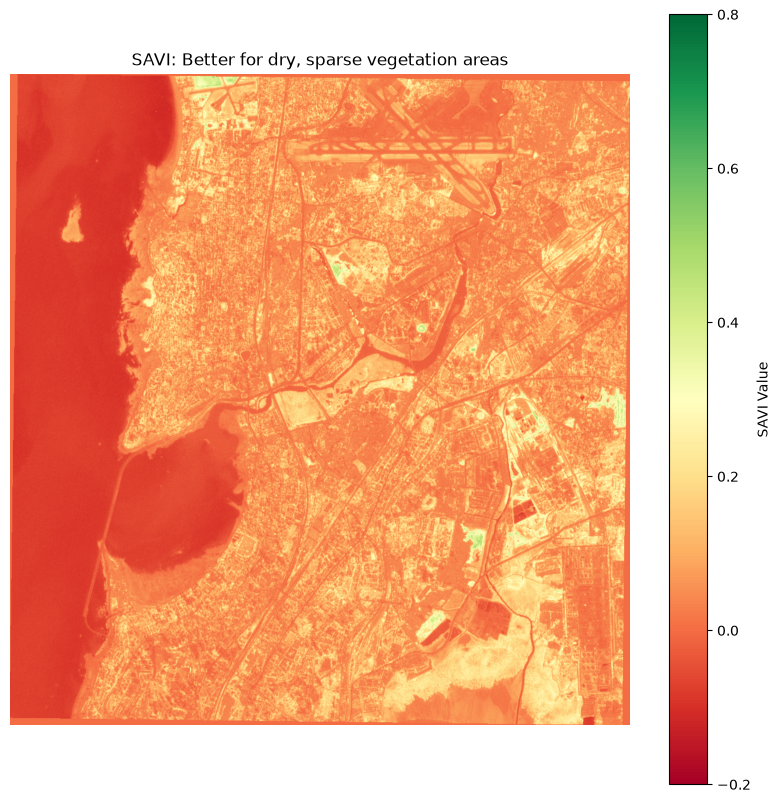

In [3]:
# Cell 3
L = 0.5 # Standard soil adjustment factor

savi_bottom = (nir + red + L)
savi = np.where(savi_bottom == 0, 0, ((nir - red) / savi_bottom) * (1 + L))

plt.figure()
plt.imshow(savi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.colorbar(label='SAVI Value')
plt.title("SAVI: Better for dry, sparse vegetation areas")
plt.axis("off")
plt.show()


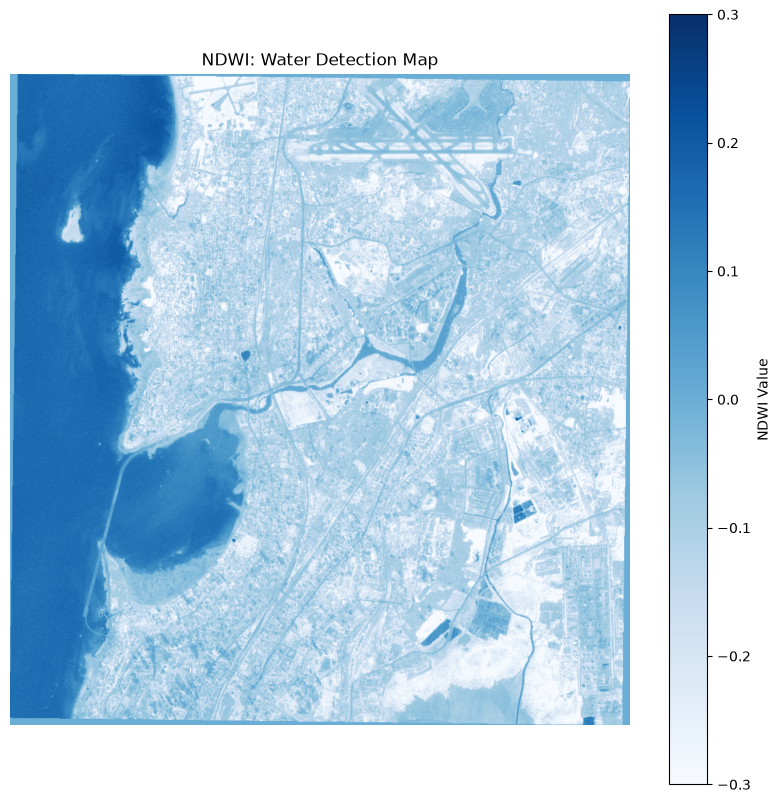

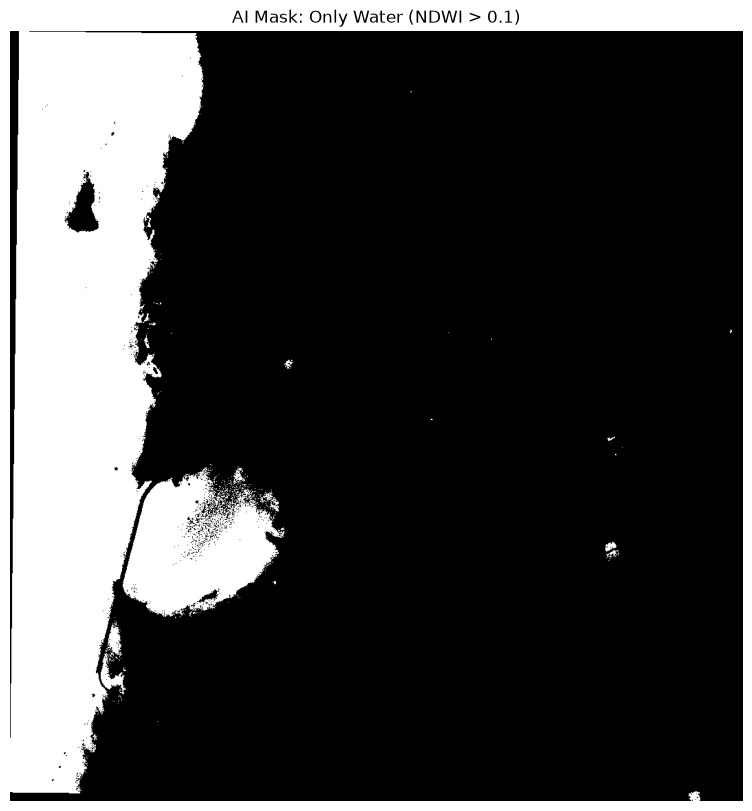

In [4]:
# Cell 4
ndwi_bottom = (green + nir)
ndwi = np.where(ndwi_bottom == 0, 0, (green - nir) / ndwi_bottom)

plt.figure()
# We use a 'Blues' colormap. Water will be dark blue.
plt.imshow(ndwi, cmap='Blues', vmin=-0.3, vmax=0.3)
plt.colorbar(label='NDWI Value')
plt.title("NDWI: Water Detection Map")
plt.axis("off")
plt.show()

# Isolate ONLY the water
water_mask = (ndwi > 0.1) # Threshold for water

plt.figure()
plt.imshow(water_mask, cmap='gray')
plt.title("AI Mask: Only Water (NDWI > 0.1)")
plt.axis("off")
plt.show()
